In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('D:/Broadway/Data Science - 2/HR_Dataset Refresh.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [3]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Gender', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [4]:
features = ['PerfScoreID', 'Salary', 'PositionID', 'EngagementSurvey', 'EmpSatisfaction','SpecialProjectsCount', 'DaysLateLast30','Absences']
target = 'Termd' # 0 -> Active , 1 -> Termination

In [5]:
X = df[features]
Y = df[target]

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, 
    stratify=Y # for equal distribution of target values
)

In [7]:
scaler = StandardScaler()

In [8]:
X_train_scale = scaler.fit_transform(X_train) # Xi-mean/sd
X_test_scale = scaler.transform(X_test)

In [23]:
model = LogisticRegression(
    solver='liblinear', class_weight='balanced', random_state=42
)

In [24]:
model.fit(X_train_scale, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [26]:
Y_pred = model.predict(X_test_scale)

In [27]:
# X -> Actual Record CM -> Predicted
# Y -> Predicted Record CM -> Actual

In [12]:
cm = confusion_matrix(Y_test, Y_pred)
cr = classification_report(Y_test, Y_pred)

In [13]:
print(cm)

[[53 25]
 [15 24]]


In [14]:
print(cr)

              precision    recall  f1-score   support

           0       0.78      0.68      0.73        78
           1       0.49      0.62      0.55        39

    accuracy                           0.66       117
   macro avg       0.63      0.65      0.64       117
weighted avg       0.68      0.66      0.67       117



In [15]:
# weighted avg -> precision

# (precision[0]*support)+(precision[1]*support)/117

# macro avg -> Precision
# precision[0]+Precision[1]/2

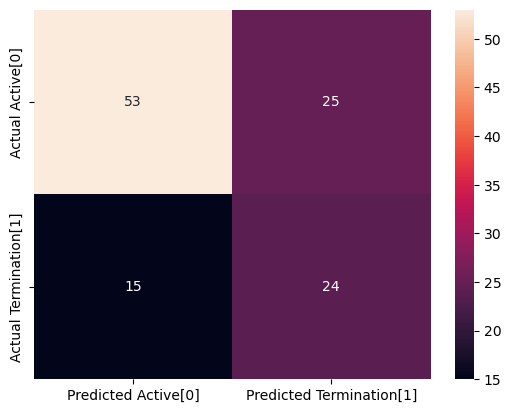

In [35]:
sns.heatmap(cm, annot=True, xticklabels=['Predicted Active[0]', 'Predicted Termination[1]'],
           yticklabels=['Actual Active[0]', 'Actual Termination[1]'])
plt.savefig('cm.png')

In [18]:
# True Negative           False Positive
# False Negative          True Positive

In [36]:
input_data = {
    'PerfScoreID': [1, 1, 4], 
    'Salary': [50000, 60000, 10000], 
    'PositionID': [0, 1, 3], 
    'EngagementSurvey': [4.6, 3, 2.2], 
    'EmpSatisfaction': [3, 4, 5],
    'SpecialProjectsCount': [3, 5, 10], 
    'DaysLateLast30': [0, 0, 1],
    'Absences': [4, 2, 0]
}

In [37]:
X_new = pd.DataFrame(input_data)

In [38]:
X_new_scale = scaler.transform(X_new)

In [39]:
Y_new_pred = model.predict(X_new_scale)

In [43]:
X_new['Predicted_Status'] = Y_new_pred
X_new['Predicted_Status'] = X_new['Predicted_Status'].replace({1: 'Likely to be Termimate',
                                                               0: 'Likely to be Active'})

In [44]:
X_new

,PerfScoreID,Salary,PositionID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,Predicted_Status
0,1,50000,0,4.6,3,3,0,4,Likely to be Termimate
1,1,60000,1,3.0,4,5,0,2,Likely to be Termimate
2,4,10000,3,2.2,5,10,1,0,Likely to be Active


In [59]:
cv = pd.read_csv('D:/Broadway/Data Science - 2/Cardiovascular_Disease.csv')

In [67]:
cv

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52.712329,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,61.920548,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52.235616,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61.454795,1,163,72.0,135,80,1,2,0,0,0,1


In [61]:
cv['age'] = cv['age']/365

In [65]:
filtered_data = cv['ap_hi'] > 180

In [66]:
cv[filtered_data]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
101,136,51.282192,1,167,80.0,190,90,2,1,0,1,0,0
559,805,55.972603,2,173,101.0,200,1000,1,1,0,0,1,1
649,928,49.835616,1,166,57.0,190,1100,1,1,0,0,1,1
965,1341,54.126027,1,155,83.0,190,90,2,2,0,0,1,1
1328,1863,57.706849,2,174,106.0,220,120,3,3,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69329,99019,54.295890,1,145,62.0,240,130,1,1,0,0,0,1
69370,99089,40.263014,1,170,74.0,2000,100,2,1,0,0,1,1
69405,99139,56.213699,1,159,60.0,190,120,1,1,0,0,0,0
69440,99182,63.400000,2,180,123.0,190,99,2,1,0,0,0,1


In [ ]:
# Content-based filtering
# Colaborative Filtering
# Hybrid Filtering -> Content + Colaborative

# Cold Start Problem